In [1]:
# STEP 1: Create Dataset (Simulated Sensor Data)
import pandas as pd
import numpy as np

np.random.seed(42)

time = pd.date_range(start="2024-01-01", periods=100, freq="H")

data = {
    "time": time,
    "temperature": np.random.normal(70, 5, 100),
    "vibration": np.random.normal(5, 1, 100),
    "pressure": np.random.normal(30, 3, 100)
}

df = pd.DataFrame(data)

# Inject anomalies
df.loc[20, "temperature"] = 100
df.loc[50, "vibration"] = 12

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_46704\1446851061.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time = pd.date_range(start="2024-01-01", periods=100, freq="H")


,time,temperature,vibration,pressure
0,2024-01-01 00:00:00,72.483571,3.584629,31.073362
1,2024-01-01 01:00:00,69.308678,4.579355,31.682354
2,2024-01-01 02:00:00,73.238443,4.657285,33.249154
3,2024-01-01 03:00:00,77.615149,4.197723,33.161406
4,2024-01-01 04:00:00,68.829233,4.838714,25.866992


In [2]:
# STEP 2: Understand Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time         100 non-null    datetime64[ns]
 1   temperature  100 non-null    float64       
 2   vibration    100 non-null    float64       
 3   pressure     100 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 3.3 KB


In [3]:
df.describe()

,time,temperature,vibration,pressure
count,100,100.000000,100.000000,100.000000
mean,2024-01-03 01:30:00.000000256,69.707485,5.089800,30.194689
min,2024-01-01 00:00:00,56.901274,3.081229,20.276198
25%,2024-01-02 00:45:00,66.995472,4.194339,28.033669
50%,2024-01-03 01:30:00,69.365219,5.084107,30.293087
75%,2024-01-04 02:15:00,72.029760,5.596560,32.113312
max,2024-01-05 03:00:00,100.000000,12.000000,41.558194
std,NaN,5.417896,1.181591,3.252849


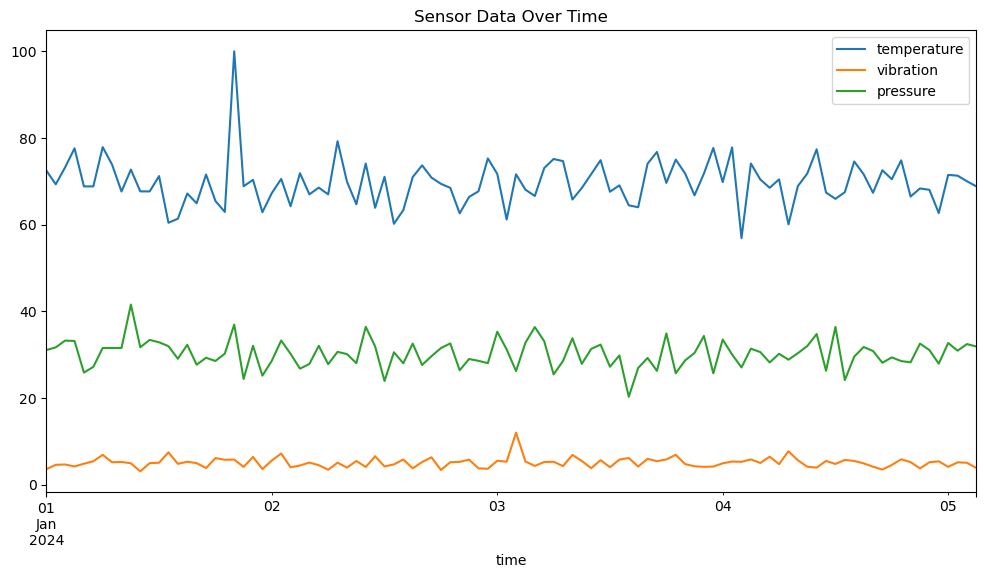

In [4]:
# STEP 3: Time-Series Visualization
import matplotlib.pyplot as plt

df.set_index("time", inplace=True)

df.plot(figsize=(12,6))
plt.title("Sensor Data Over Time")
plt.show()

In [5]:
# STEP 4: Anomaly Detection (CORE PART 🔥)
# Z-score method
from scipy.stats import zscore

df["temp_z"] = zscore(df["temperature"])

# Anomaly if |z| > 3
df["anomaly"] = df["temp_z"].abs() > 3

df[df["anomaly"] == True]

,temperature,vibration,pressure,temp_z,anomaly
time,,,,,
2024-01-01 20:00:00,100.0,5.791032,36.943976,5.619363,True


In [7]:
# STEP 5: Multi-Sensor Insight (IMPORTANT)
df[["temperature", "vibration", "pressure"]].corr()

,temperature,vibration,pressure
temperature,1.000000,-0.044411,0.247649
vibration,-0.044411,1.000000,-0.100116
pressure,0.247649,-0.100116,1.000000


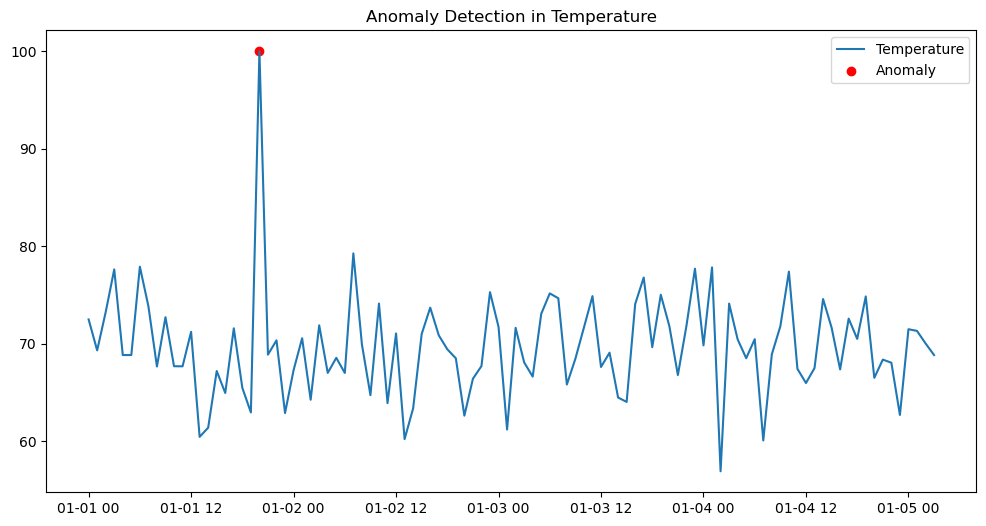

In [9]:
# STEP 6: Plot Anomalies
plt.figure(figsize=(12,6))

plt.plot(df.index, df["temperature"], label="Temperature")

# Highlight anomalies
plt.scatter(df[df["anomaly"]].index,
            df[df["anomaly"]]["temperature"],
            color="red", label="Anomaly")

plt.legend()
plt.title("Anomaly Detection in Temperature")
plt.show()